# 🧠 Розпізнавання облич

Розпізнавання облич — одна з найвідоміших задач комп’ютерного зору. Вона включає:
- 🔍 **Детекцію облич** — знаходження облич на зображенні.
- 🆔 **Ідентифікацію облич** — визначення, хто зображений.

---

## 🔍 Детекція облич

Детекція облич — це процес виявлення облич на зображеннях або відео. Це перший крок перед розпізнаванням особи.

### 🚀 Сучасні методи:
- Будь яка модель для детекції обʼєктів.

---

## 🆔 Ідентифікація облич

Після детекції переходимо до ідентифікації — встановлення особи.
Ідентифікація відповідає на питання: кому належить це обличчя?

### 🔄 Типовий пайплайн:
1. 📐 **Вилучення ознак** — Кодування вхідного зображення обличчя в вектор ознак.
2. 🧬 **Порівняння ознак** — Вилучений вектор порівнюється з іншими векторами в базі даних облич заздалегідь створеноі.

### 🏋️‍♂️ Тренування (Метричне навчання)

Для навчання моделей розпізнавання облич найчастіше використовують не класичну класифікацію, а **метричне навчання** (metric learning). Мета — навчити мережу відображати кожне обличчя у вектор (embedding), який:
- 🧲 близький до векторів тієї ж особи,
- 🚫 і далекий від векторів інших осіб.

Цей підхід дозволяє:
- 🔄 Додавати нові обличчя без повного перенавчання моделі.
- 🔍 Проводити верифікацію чи ідентифікацію через просте порівняння векторів.

---

#### 🧩 Тріплет лос (Triplet Loss)

**Triplet loss** — ключова функція втрат, яка навчає модель розрізняти обличчя.

Кожен тренувальний приклад — це **трійка зображень**:
- 🟢 **Anchor** — обличчя певної особи.
- 🟢 **Positive** — інше обличчя тієї ж особи.
- 🔴 **Negative** — обличчя іншої особи.

Цільова функція намагається зробити:
- відстань між `Anchor` і `Positive` якнайменшою,
- відстань між `Anchor` і `Negative` якнайбільшою,
- причому різниця має бути більшою за деякий **margin** (порогову відстань).

Формально: $L = max( ||f(a) − f(p)||² − ||f(a) − f(n)||² + α, 0)$
де:
- `f(x)` — вектор ознак (embedding) зображення `x`,
- `a`, `p`, `n` — anchor, positive, negative,
- `α` (alpha) — margin (зазвичай 0.2 або 0.5).

Ця формула вам має бути знайома по другій лекціі де ми розглядали **SVM**.
А саме **hinge loss**. Ця помилка використовувалась для збільшення маржи між позитивними та негативними класами.

🔧 Якщо різниця відстаней уже більша за α, то тріплет не впливає на втрати — тому важливо правильно підбирати **"важкі" тріплети** (hard triplets).

---

#### 📈 Переваги triplet loss:
- 🔁 Універсальність: працює незалежно від кількості класів.
- 💡 Не вимагає жорсткої класифікації, тільки відносних відстаней.
- 📦 Можна легко масштабувати на мільйони осіб.

#### ⚠️ Недоліки:
- 🐌 Складність навчання: потрібно вибирати "корисні" тріплети.
- 🧮 Високе навантаження при генерації тріплетів у великих датасетах.
- 🤯 Можлива нестабільність градієнтів на початку тренування.

#### ⚙️ Інші функції помилок

Окрім Triplet Loss, у задачах розпізнавання облич широко використовуються інші loss-функції, які забезпечують краще розділення embedding-векторів у просторах ознак.

---

- 🛡️ **ArcFace** — *Additive Angular Margin Loss*  
  Додає фіксований **кутовий margin** до кута між вектором ознак та вагою класу в нормалізованому просторі.  
  Завдяки цьому мережа вчиться розділяти класи **кутово**, що відповідає реальній геометрії embedding-простору.  
  ✅ Найпопулярніший loss у сучасних системах розпізнавання облич.

---

- 🔵 **CosFace** — *Large Margin Cosine Loss*  
  Варіант з **косинусною відстанню**: додає margin прямо до значення `cos(θ)`, тобто зсуває його на фіксовану величину.  
  Простий в реалізації та швидкий у тренуванні.  
  ✔️ Трохи поступається ArcFace по точності, але легший у стабілізації.

---

- ⚪ **SphereFace** — *Angular Softmax Loss*  
  Вводить **множник до кута** між embedding та вектором класу: `cos(mθ)`, де `m > 1`.  
  Це створює більш складну нелінійну межу між класами, що **ускладнює тренування**, але покращує відокремлення класів.  
  ❗ Має нестабільні градієнти, потребує обережного налаштування.

---

- 🧬 **Contrastive Loss**  
  Працює з **парами зображень**, не з трійками.  
  Мета: зблизити пари однієї особи та віддалити пари різних осіб.  
  Формула:

### 🏗️ Популярні моделі та бібліотеки:
- **face_recognition** - All-in-one бібліотека для детекціі та ідентифікаціі облич.
- 🧠 **FaceNet** — triplet loss для навчання embedding-простору.
- 🛡️ **ArcFace**, **CosFace** — покращують відокремлення векторів різних осіб.
- 🛠️ **InsightFace**, **Dlib ResNet**, **VGGFace** — відкриті реалізації для практичного використання.
 

## Ідентифікація облич в коді
Ми спробуємо створити власну модель для ідентифікаціі облич на базі resnet34.

### 📥 Завантаження даних

Для тренування моделі ми використаємо публічний датасет **LFW (Labeled Faces in the Wild)**, який містить понад **13 000 зображень** облич **5749 різних осіб**. Датасет широко використовується для задач:
- 🔍 Верифікації облич (чи це та сама особа?),
- 🧑‍🎓 Ідентифікації (хто це?),
- 🧪 Тестування generalization в обличчєвих моделях.

Кількість зображень: 9164
Форма одного зображення: (62, 47)
Кількість унікальних осіб: 1680


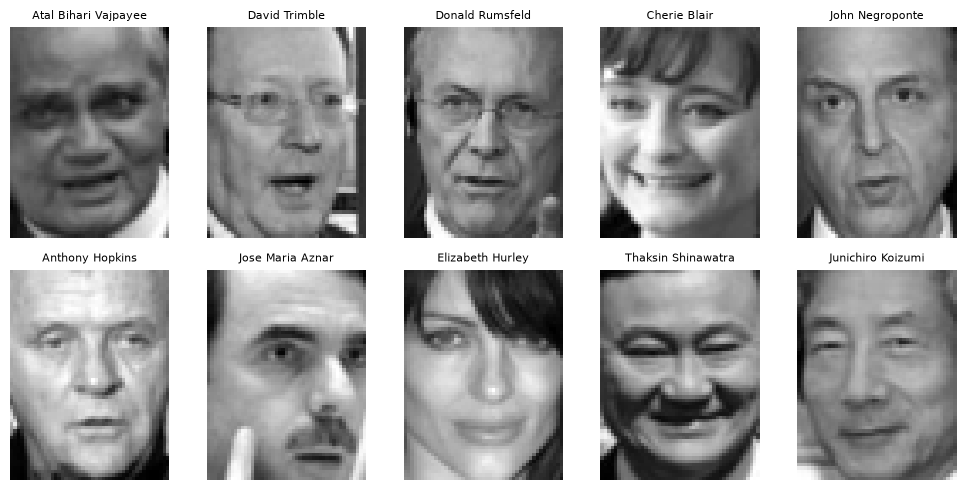

In [2]:
from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt

# 📦 Завантаження LFW-датасету з мінімум 20 зображень на особу
lfw = fetch_lfw_people(min_faces_per_person=2, resize=0.5)

print(f"Кількість зображень: {lfw.images.shape[0]}")
print(f"Форма одного зображення: {lfw.images[0].shape}")
print(f"Кількість унікальних осіб: {len(lfw.target_names)}")

# 🔎 Візуалізація кількох прикладів
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, image, label in zip(axes.ravel(), lfw.images, lfw.target):
    ax.imshow(image, cmap="gray")
    ax.set_title(lfw.target_names[label], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:

from torch.utils.data import Dataset, DataLoader
import torch
import torchvision.transforms as transforms
import random
import os
import numpy as np

class FaceContrastiveDataset(Dataset):
    """
    Dataset for contrastive learning using LFW dataset.
    Returns pairs of images: (anchor, positive) or (anchor, negative).
    """
    def __init__(self, lfw_dataset, transform=None):
        """
        Args:
            lfw_dataset (sklearn.utils.Bunch): The LFW dataset loaded with fetch_lfw_people.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.lfw_dataset = lfw_dataset
        self.transform = transform
        self.images = lfw_dataset.images # Images are numpy arrays
        self.labels = lfw_dataset.target # Labels are integers
        self.target_names = lfw_dataset.target_names # Names of the people

        # Create a dictionary to map label (person ID) to list of image indices
        self.label_to_indices = {}
        for i, label in enumerate(self.labels):
            if label not in self.label_to_indices:
                self.label_to_indices[label] = []
            self.label_to_indices[label].append(i)

        # Filter out persons with only one image, as we need at least two for positive pairs
        self.valid_labels = [label for label, indices in self.label_to_indices.items() if len(indices) >= 2]
        self.valid_indices = [idx for label in self.valid_labels for idx in self.label_to_indices[label]]


    def __len__(self):
        # We generate pairs, so the length is the number of valid images
        return len(self.valid_indices)

    def __getitem__(self, index):
        """
        Generates a triplets of images (anchor, positive, negative)
        """
        # Get an anchor image index from the pool of valid indices
        anchor_index = self.valid_indices[index]
        anchor_label = self.labels[anchor_index]

        positive_index = anchor_index
        while positive_index == anchor_index:
            positive_index = random.choice(self.label_to_indices[anchor_label])

        anchor = self.images[anchor_index]
        positive = self.images[positive_index]

            # Get a negative example (an image of a different person)
        negative_label = anchor_label
        while negative_label == anchor_label:
            negative_label = random.choice(self.valid_labels) # Select a different valid person

        negative_index = random.choice(self.label_to_indices[negative_label])

        negative = self.images[negative_index]

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

# Example Usage:

# Define transforms
# Note: LFW images are grayscale. If your model expects 3 channels,
# you might need to repeat the channel like transforms.Lambda(lambda x: x.repeat(3, 1, 1))
transform = transforms.Compose([
    transforms.ToTensor(), # Convert numpy array to PyTorch Tensor (scales to [0, 1])
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    # transforms.Normalize(mean=[0.5], std=[0.5]) # Example normalization for grayscale
])

# Create the dataset and dataloader
face_dataset = FaceContrastiveDataset(lfw_dataset=lfw, transform=transform)
dataloader = DataLoader(face_dataset, batch_size=32, shuffle=True)

print(f"Number of valid samples in dataset: {len(face_dataset)}")

# Iterate through a batch
for anchor, positive, negative in dataloader:
    print("Batch of anchors shape:", anchor.shape)
    print("Batch of positives shape:", positive.shape)
    print("Batch of negatives shape:", negative.shape)
    break # Just show one batch

 

Number of valid samples in dataset: 9164
Batch of anchors shape: torch.Size([32, 3, 62, 47])
Batch of positives shape: torch.Size([32, 3, 62, 47])
Batch of negatives shape: torch.Size([32, 3, 62, 47])


In [5]:
from torchvision.models import resnet34
from torch import nn

# Define a simple CNN model for embedding
class FaceEmbedder(nn.Module):
    def __init__(self):
        super(FaceEmbedder, self).__init__()
        self.model = resnet34(pretrained=True)
        self.model.fc = nn.Sequential(
            nn.Linear(self.model.fc.in_features, 512), # Adjust input size based on image size and conv layers
            nn.ReLU(),
            nn.Linear(512, 128) # Embedding size
        )

    def forward(self, x):
        x = self.model(x)
        x = nn.functional.normalize(x, p=2, dim=1)
        return x
 

In [6]:
# Define the Triplet Loss function
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        distance_positive = (anchor - positive).pow(2).sum(1)  # L2 distance squared
        distance_negative = (anchor - negative).pow(2).sum(1)  # L2 distance squared
        losses = torch.relu(distance_positive - distance_negative + self.margin)
        return losses.mean()

In [ ]:
from torch import optim
from tqdm import tqdm

# Initialize model, loss, and optimizer

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch_directml.device() 
print(f"Використовується пристрій: {device}") # Виведе щось на кшталт 'privateuseone:0'

model = FaceEmbedder().to(device)
criterion = TripletLoss(margin=1.0)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.001, total_iters=10)

# Training loop
num_epochs = 10

print("Starting training...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    processed_batches = 0
    for i, data in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        anchor_img, positive_img, negative_img = data
        # Skip batch if any image failed to load
        if anchor_img is None:
            continue

        anchor_img = anchor_img.to(device)
        positive_img = positive_img.to(device)
        negative_img = negative_img.to(device)

        optimizer.zero_grad()

        # Get embeddings
        anchor_embedding = model(anchor_img)
        positive_embedding = model(positive_img)
        negative_embedding = model(negative_img)

        # Calculate loss
        loss = criterion(anchor_embedding, positive_embedding, negative_embedding)

        # Backpropagate and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        processed_batches += 1

    scheduler.step()

    if processed_batches > 0:
        avg_loss = running_loss / processed_batches
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    else:
        print(f"Epoch {epoch+1}, No batches processed.")


print("Training finished.")


 

cpu
Starting training...


Epoch 1/10: 100%|██████████| 287/287 [02:26<00:00,  1.96it/s]


Epoch 1, Loss: 0.6778


Epoch 2/10: 100%|██████████| 287/287 [02:27<00:00,  1.95it/s]


Epoch 2, Loss: 0.5585


...

Epoch 8/10: 100%|██████████| 287/287 [02:27<00:00,  1.95it/s]


Epoch 8, Loss: 0.2668


Epoch 9/10: 100%|██████████| 287/287 [02:26<00:00,  1.96it/s]


Epoch 9, Loss: 0.1507


Epoch 10/10:  75%|███████▌  | 216/287 [01:48<00:35,  2.03it/s]

In [11]:
# You can save the trained model
torch.save(model.state_dict(), 'face_embedder.pth')

# --- Example Usage (after training) ---
# Load the trained model (if saved)
model = FaceEmbedder().to(device)
model.load_state_dict(torch.load('face_embedder.pth'))
model.eval() # Set model to evaluation mode

FaceEmbedder(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, 

In [14]:

# Function to get embedding for a single image
def get_embedding(img, model, transform, device):
    img = transform(img).unsqueeze(0).to(device) # Add batch dimension
    with torch.no_grad():
        embedding = model(img)
    return embedding.squeeze(0).cpu().numpy() # Remove batch dimension and convert to numpy

# Define a function to calculate cosine similarity between two embeddings
def cosine_similarity(emb1, emb2):
    return np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

# Define a function to calculate Euclidean distance between two embeddings
def euclidean_distance(emb1, emb2):
    return np.linalg.norm(emb1 - emb2)

In [7]:
# prompt: update showing examples of trained model working, using scikit variation of dataset

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
# Choose a few pairs of images from the validation set for testing
# Select some pairs of the same person and some pairs of different people
# You might need to manually inspect the dataset structure or use the dataset object
# to find image paths for specific individuals.

# Example: Find images of specific individuals from the original LFW dataset (not the YOLO prepared one)
# Assuming `lfw` dataset is available from the previous cell

person1_name = 'Gerhard Schroeder'
person2_name = 'Donald Rumsfeld'
person3_name = 'George W Bush'

# Find indices for these people in the original lfw dataset
person1_indices = np.argwhere(lfw.target == np.argwhere(lfw.target_names == person1_name)[0][0])[:, 0]
person2_indices = np.argwhere(lfw.target == np.argwhere(lfw.target_names == person2_name)[0][0])[:, 0]
person3_indices = np.argwhere(lfw.target == np.argwhere(lfw.target_names == person3_name)[0][0])[:, 0]

# Select a few image paths
if len(person1_indices) >= 2:
    p1_img1_data = lfw.images[person1_indices[0]]
    p1_img2_data = lfw.images[person1_indices[1]]

if len(person2_indices) >= 1 and len(person1_indices) >= 1:
    p2_img1_data = lfw.images[person2_indices[0]]
    p1_img3_data = lfw.images[person1_indices[-1]]


# Prepare images for the model (convert to PIL and apply transform)
# Note: The FaceEmbedder was trained on 1-channel images (converted from grayscale LFW to Tensor).
# If you modified the model or transform to handle 3 channels, adjust accordingly.
# Let's assume the model was trained on 1-channel input as per the dataset creation.
transform_inference = transforms.Compose([
    transforms.ToPILImage(), # Convert numpy array to PIL Image
    transforms.ToTensor(),   # Convert PIL Image to PyTorch Tensor (scales to [0, 1])
    # If model expects 3 channels and transform didn't handle it during training, add repeat here:
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
])

# Get embeddings for the selected images
embedding_p1_img1 = get_embedding(p1_img1_data, model, transform_inference, device)
embedding_p1_img2 = get_embedding(p1_img2_data, model, transform_inference, device)
embedding_p2_img1 = get_embedding(p2_img1_data, model, transform_inference, device)
embedding_p1_img3 = get_embedding(p1_img3_data, model, transform_inference, device) # Different image of person 1

# Calculate similarity/distance for pairs
similarity_same_person = cosine_similarity(embedding_p1_img1, embedding_p1_img2)
distance_same_person = euclidean_distance(embedding_p1_img1, embedding_p1_img2)

similarity_different_person1 = cosine_similarity(embedding_p1_img1, embedding_p2_img1)
distance_different_person1 = euclidean_distance(embedding_p1_img1, embedding_p2_img1)


# Print results
print("\n--- Face Identification Examples ---")
print(f"Comparing '{person1_name}' (Image 1) and '{person1_name}' (Image 2):")
print(f"  Cosine Similarity: {similarity_same_person:.4f}")
print(f"  Euclidean Distance: {distance_same_person:.4f}")

print(f"\nComparing '{person1_name}' (Image 1) and '{person2_name}' (Image 1):")
print(f"  Cosine Similarity: {similarity_different_person1:.4f}")
print(f"  Euclidean Distance: {distance_different_person1:.4f}")

# Visualize the pairs
fig, axes = plt.subplots(2, 2, figsize=(15, 5))

# Pair 1: Same person
axes[0, 0].imshow(p1_img1_data, cmap="gray")
axes[0, 0].set_title(f"{person1_name}", fontsize=10)
axes[0, 0].axis("off")

axes[0, 1].imshow(p1_img2_data, cmap="gray")
axes[0, 1].set_title(f"{person1_name}\nSim: {similarity_same_person:.2f}", fontsize=10)
axes[0, 1].axis("off")

# Pair 2: Different person 1
axes[1, 0].imshow(p1_img1_data, cmap="gray")
axes[1, 0].set_title(f"{person1_name}", fontsize=10)
axes[1, 0].axis("off")

axes[1, 1].imshow(p2_img1_data, cmap="gray")
axes[1, 1].set_title(f"{person2_name}\nSim: {similarity_different_person1:.2f}", fontsize=10)
axes[1, 1].axis("off")



plt.tight_layout()
plt.show()


NameError: name 'get_embedding' is not defined